In [1]:
import pandas as pd

df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-200*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

2024-07-11 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']


In [2]:

window_step_length = 6
window_size = 50
num_test_points = 200

horizon = 5 #3 is good
target_idx = 0



Shape dataset (6409, 11)
means:  Close           1.043935e+02
Volume          4.174720e+06
MarketCap       1.099524e+11
Weight          3.379463e-02
Return          5.710548e-04
LogReturn       3.715475e-04
WeightedRet     2.191627e-05
SMA20           1.040219e+02
EMA20           1.040130e+02
RSI14           5.227815e+01
ReturnVola20    1.814528e-02
dtype: float64
stds:  Close           8.875950e+01
Volume          4.600011e+06
MarketCap       9.348594e+10
Weight          1.282733e-02
Return          2.000137e-02
LogReturn       1.996333e-02
WeightedRet     6.095575e-04
SMA20           8.849015e+01
EMA20           8.844715e+01
RSI14           1.056618e+01
ReturnVola20    8.856161e-03
dtype: float64


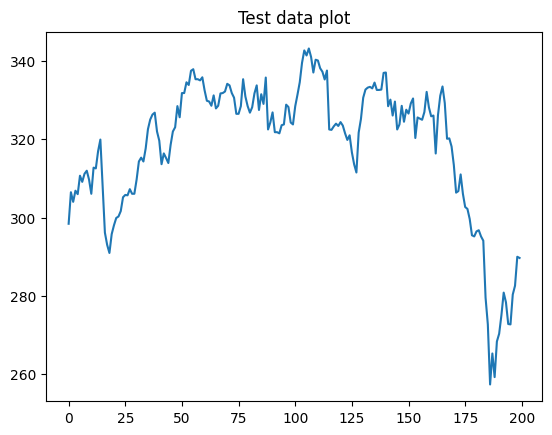

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.4914475388099575
Normalized Benchmark: 0.031322621086138695


/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ train │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

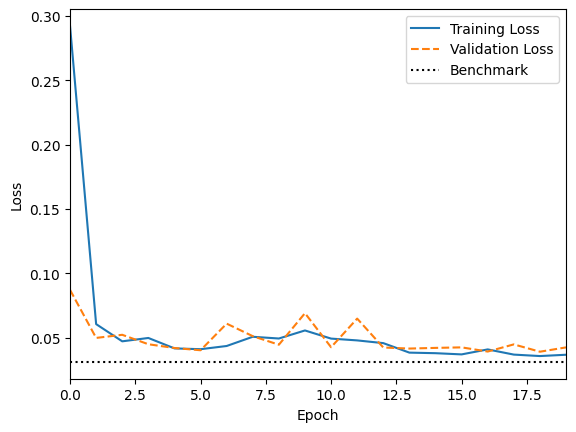

variance of returns for old data:  0.0016906810731469183
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(292.0483)
windows last2 price:  tensor(290.4776)
windows last3 price:  tensor(295.1897)
period from idx:  0  to idx  5
prediction at 5:  tensor(286.3687)
last price from test data:  292.0483093261719
real price 5 steps forward:  tensor(310.7002)
kelly weight:  {tensor(-11.5028, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(310.7002)
windows last2 price:  tensor(305.9881)
windows last3 price:  tensor(306.8716)
period from idx:  5  to idx  10
prediction at 5:  tensor(305.7523)
last price from test data:  tensor(305.9881)
real price 5 steps forward:  tensor(306.0862)
kelly weight:  {tensor(-0.4559, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(306.0862)
windows last2 price:  tensor(309.7185)
windows last3 

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


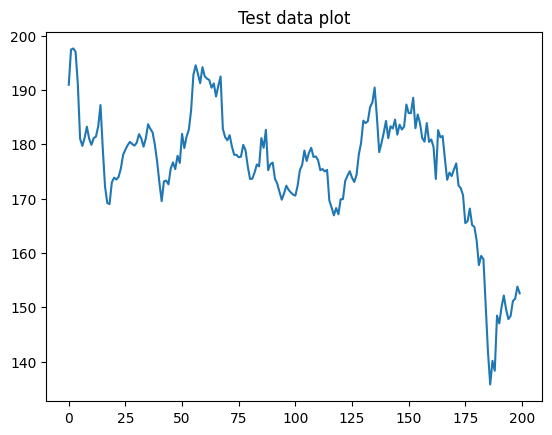

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.1106915169189548
Normalized Benchmark: 0.025260929006409655


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

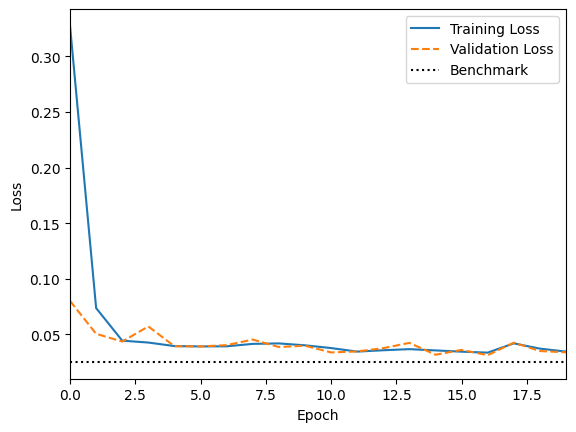

variance of returns for old data:  0.0019394698002447816
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(189.3760)
windows last2 price:  tensor(189.9653)
windows last3 price:  tensor(192.6665)
period from idx:  0  to idx  5
prediction at 5:  tensor(190.2563)
last price from test data:  189.37600708007807
real price 5 steps forward:  tensor(181.0270)
kelly weight:  {tensor(2.3967, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(181.0269)
windows last2 price:  tensor(191.0458)
windows last3 price:  tensor(197.0375)
period from idx:  5  to idx  10
prediction at 5:  tensor(188.3775)
last price from test data:  tensor(191.0458)
real price 5 steps forward:  tensor(179.8974)
kelly weight:  {tensor(-7.2013, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(179.8974)
windows last2 price:  tensor(181.0269)
windows last3 p

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


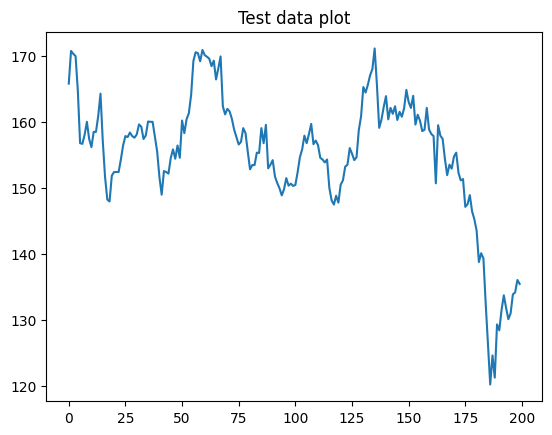

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 0.9747955631164487
Normalized Benchmark: 0.02535107763732807


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

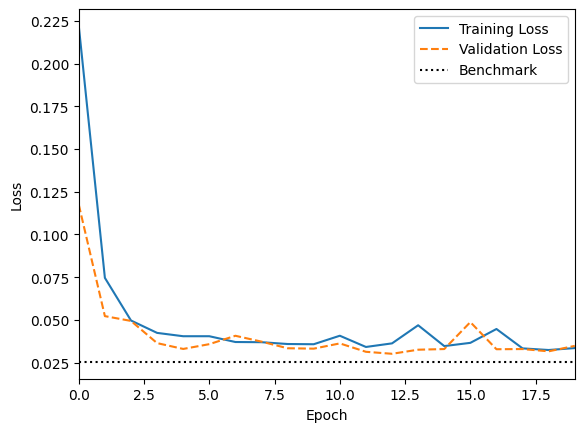

variance of returns for old data:  0.002054873405797314
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(164.0397)
windows last2 price:  tensor(163.2556)
windows last3 price:  tensor(165.4120)
period from idx:  0  to idx  5
prediction at 5:  tensor(164.5984)
last price from test data:  164.0397491455078
real price 5 steps forward:  tensor(156.7371)
kelly weight:  {tensor(1.6575, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(156.7371)
windows last2 price:  tensor(164.6769)
windows last3 price:  tensor(169.9211)
period from idx:  5  to idx  10
prediction at 5:  tensor(162.9312)
last price from test data:  tensor(164.6769)
real price 5 steps forward:  tensor(156.1490)
kelly weight:  {tensor(-5.1588, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(156.1490)
windows last2 price:  tensor(157.3743)
windows last3 pri

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


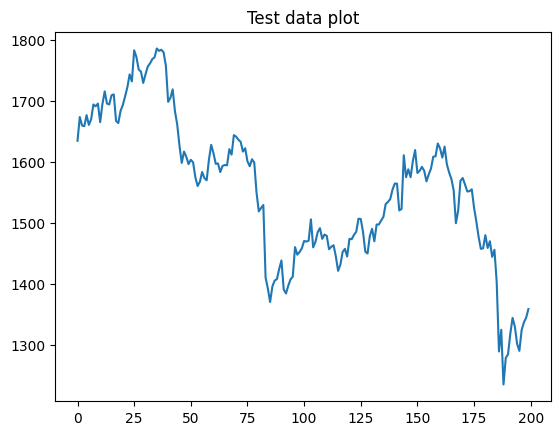

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 13.07552186632679
Normalized Benchmark: 0.036648522383339176


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

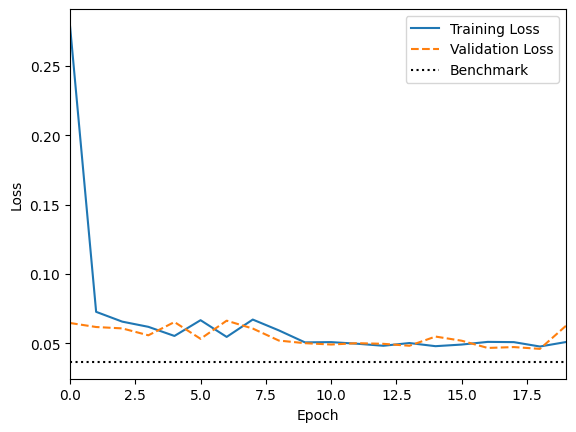

variance of returns for old data:  0.001214877051313215
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1633.0167)
windows last2 price:  tensor(1613.5463)
windows last3 price:  tensor(1626.0273)
period from idx:  0  to idx  5
prediction at 5:  tensor(1708.3180)
last price from test data:  1633.0167236328125
real price 5 steps forward:  tensor(1660.4750)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1660.4750)
windows last2 price:  tensor(1676.4507)
windows last3 price:  tensor(1658.4780)
period from idx:  5  to idx  10
prediction at 5:  tensor(1743.8645)
last price from test data:  tensor(1676.4507)
real price 5 steps forward:  tensor(1664.9681)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1664.9681)
windows last2 price:  tensor(1695.4218)
windows la

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


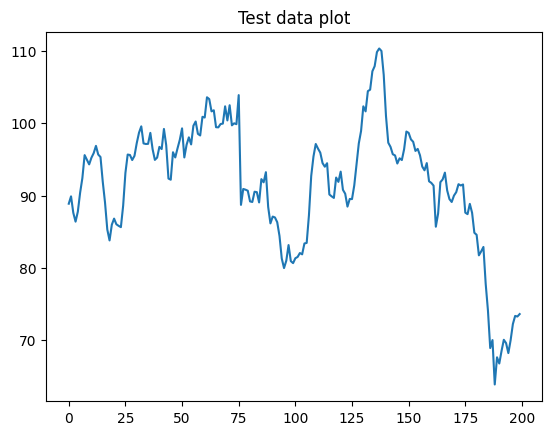

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.769086485136562
Normalized Benchmark: 0.05373043293735739


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

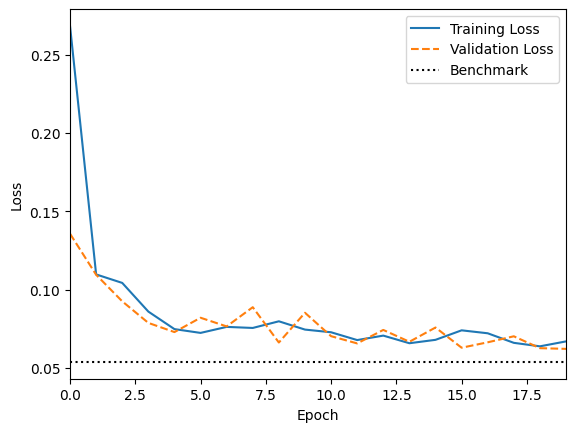

variance of returns for old data:  0.002388173897053013
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(85.6200)
windows last2 price:  tensor(86.)
windows last3 price:  tensor(86.8200)
period from idx:  0  to idx  5
prediction at 5:  tensor(89.8361)
last price from test data:  85.62000274658203
real price 5 steps forward:  tensor(90.3800)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(90.3800)
windows last2 price:  tensor(87.7800)
windows last3 price:  tensor(86.4000)
period from idx:  5  to idx  10
prediction at 5:  tensor(90.2956)
last price from test data:  tensor(87.7800)
real price 5 steps forward:  tensor(95.2400)
kelly weight:  {tensor(12.0001, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.2400)
windows last2 price:  tensor(94.3200)
windows last3 price:  tensor(94.9600)

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


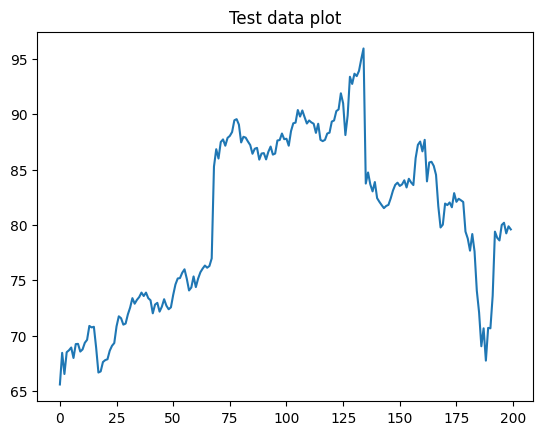

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 3.07936506037709
Normalized Benchmark: 0.05314788980046238


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

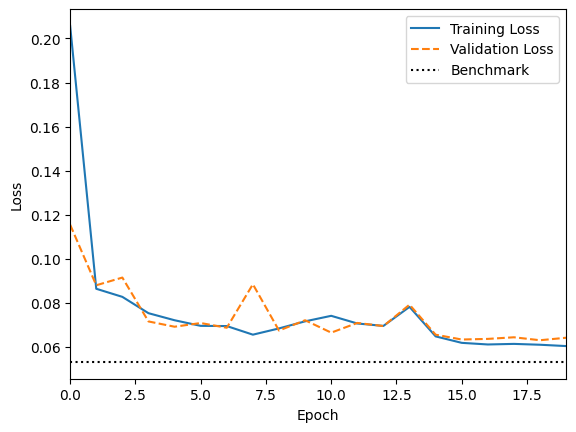

variance of returns for old data:  0.003549972517056057
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(65.6036)
windows last2 price:  tensor(65.0822)
windows last3 price:  tensor(65.5650)
period from idx:  0  to idx  5
prediction at 5:  tensor(66.9609)
last price from test data:  65.60363006591797
real price 5 steps forward:  tensor(68.9253)
kelly weight:  {tensor(5.8279, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(68.9253)
windows last2 price:  tensor(68.6743)
windows last3 price:  tensor(68.5005)
period from idx:  5  to idx  10
prediction at 5:  tensor(70.0455)
last price from test data:  tensor(68.6743)
real price 5 steps forward:  tensor(68.7515)
kelly weight:  {tensor(5.6244, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(68.7515)
windows last2 price:  tensor(68.5584)
windows last3 price:  tensor(69

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


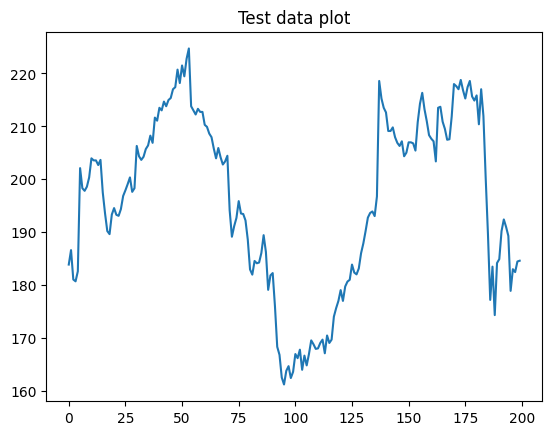

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 3.264458389454392
Normalized Benchmark: 0.04528789039402356


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

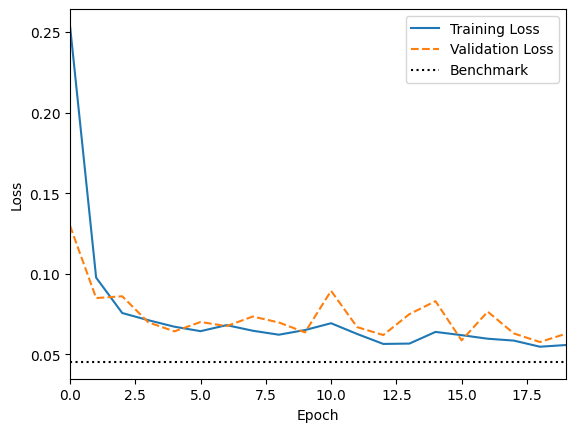

variance of returns for old data:  0.001932821581867357
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(179.4850)
windows last2 price:  tensor(177.1939)
windows last3 price:  tensor(180.8499)
period from idx:  0  to idx  5
prediction at 5:  tensor(186.6044)
last price from test data:  179.48497009277344
real price 5 steps forward:  tensor(202.1034)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(202.1034)
windows last2 price:  tensor(182.6048)
windows last3 price:  tensor(180.7036)
period from idx:  5  to idx  10
prediction at 5:  tensor(197.0150)
last price from test data:  tensor(182.6048)
real price 5 steps forward:  tensor(203.9557)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(203.9557)
windows last2 price:  tensor(200.3485)
windows last3 price:  t

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


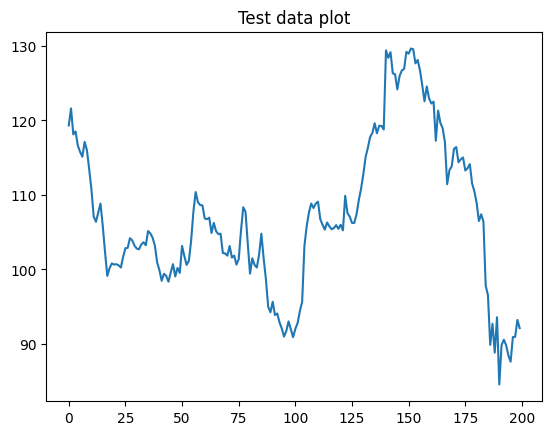

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.1271728521427902
Normalized Benchmark: 0.028273370789214113


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

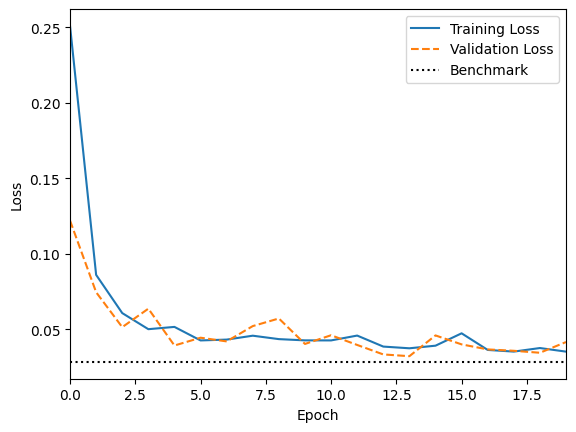

variance of returns for old data:  0.002336081454097952
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(117.2752)
windows last2 price:  tensor(117.2253)
windows last3 price:  tensor(121.1195)
period from idx:  0  to idx  5
prediction at 5:  tensor(116.4720)
last price from test data:  117.27518463134766
real price 5 steps forward:  tensor(115.7774)
kelly weight:  {tensor(-2.9317, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(115.7774)
windows last2 price:  tensor(116.6262)
windows last3 price:  tensor(118.5233)
period from idx:  5  to idx  10
prediction at 5:  tensor(115.0690)
last price from test data:  tensor(116.6262)
real price 5 steps forward:  tensor(110.7349)
kelly weight:  {tensor(-5.7155, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(110.7349)
windows last2 price:  tensor(113.4808)
windows last3 p

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


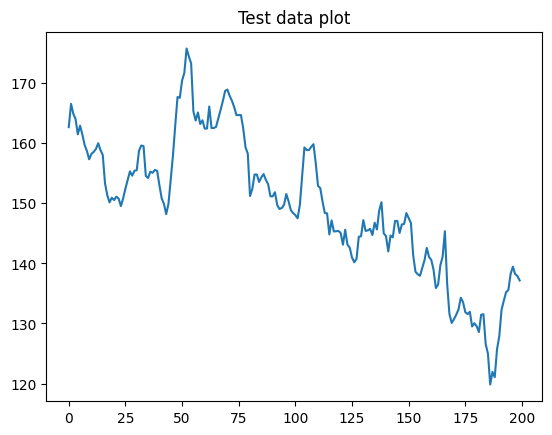

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 3.202749817391352
Normalized Benchmark: 0.06246292290441796


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

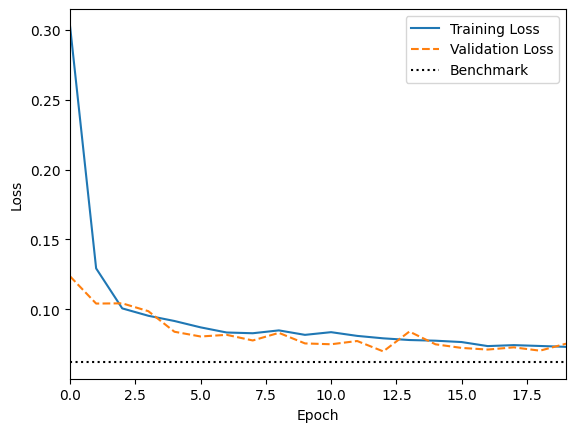

variance of returns for old data:  0.0019113254588998812
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(162.1386)
windows last2 price:  tensor(161.2309)
windows last3 price:  tensor(163.2851)
period from idx:  0  to idx  5
prediction at 5:  tensor(159.4998)
last price from test data:  162.1385955810547
real price 5 steps forward:  tensor(162.9030)
kelly weight:  {tensor(-8.5151, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(162.9030)
windows last2 price:  tensor(161.4698)
windows last3 price:  tensor(164.0017)
period from idx:  5  to idx  10
prediction at 5:  tensor(162.2278)
last price from test data:  tensor(161.4698)
real price 5 steps forward:  tensor(158.2213)
kelly weight:  {tensor(2.4560, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(158.2213)
windows last2 price:  tensor(157.3136)
windows last3 pr

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


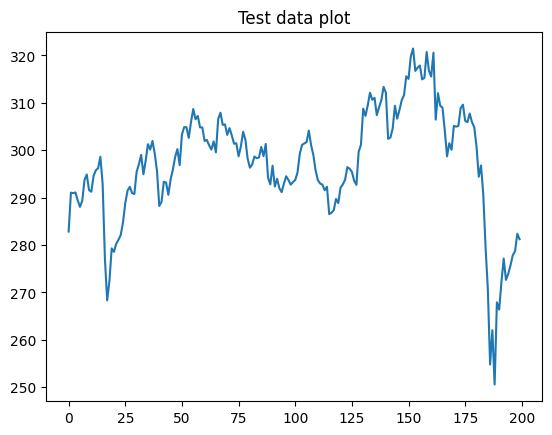

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.3772168296295009
Normalized Benchmark: 0.022124423485848407


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

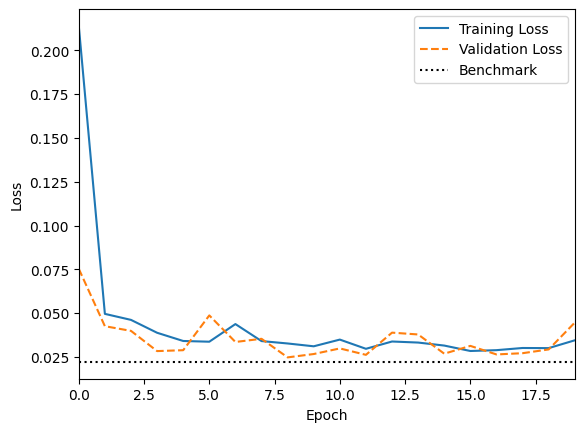

variance of returns for old data:  0.001228337918438818
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(282.0987)
windows last2 price:  tensor(282.0496)
windows last3 price:  tensor(283.1799)
period from idx:  0  to idx  5
prediction at 5:  tensor(277.8466)
last price from test data:  282.0987243652344
real price 5 steps forward:  tensor(288.0454)
kelly weight:  {tensor(-12.2711, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(288.0454)
windows last2 price:  tensor(289.4215)
windows last3 price:  tensor(291.0925)
period from idx:  5  to idx  10
prediction at 5:  tensor(283.8619)
last price from test data:  tensor(289.4215)
real price 5 steps forward:  tensor(291.2399)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(291.2399)
windows last2 price:  tensor(291.5839)
windows last3 pric

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


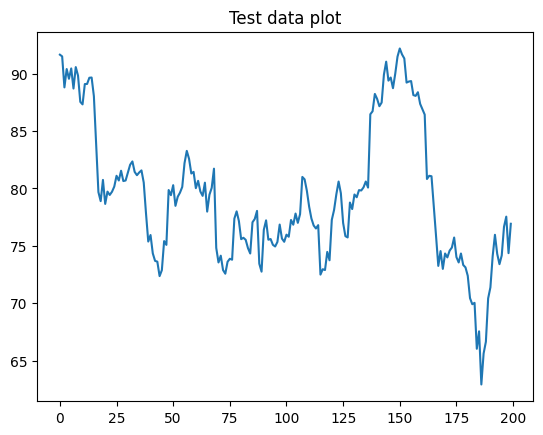

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.8832062413660196
Normalized Benchmark: 0.03867834201393457


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

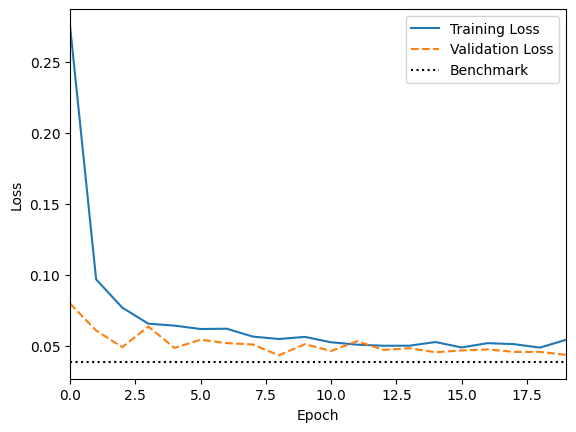

variance of returns for old data:  0.00275892560178041
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(89.5000)
windows last2 price:  tensor(91.2000)
windows last3 price:  tensor(86.9000)
period from idx:  0  to idx  5
prediction at 5:  tensor(98.1150)
last price from test data:  89.5
real price 5 steps forward:  tensor(90.4500)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(90.4500)
windows last2 price:  tensor(89.5500)
windows last3 price:  tensor(90.4000)
period from idx:  5  to idx  10
prediction at 5:  tensor(96.7412)
last price from test data:  tensor(89.5500)
real price 5 steps forward:  tensor(87.3200)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(87.3200)
windows last2 price:  tensor(87.5400)
windows last3 price:  tensor(89.8300)
period from i

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


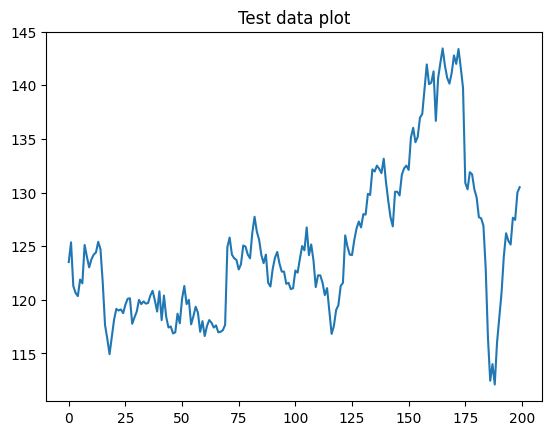

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.8196743526126706
Normalized Benchmark: 0.07114142399148023


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

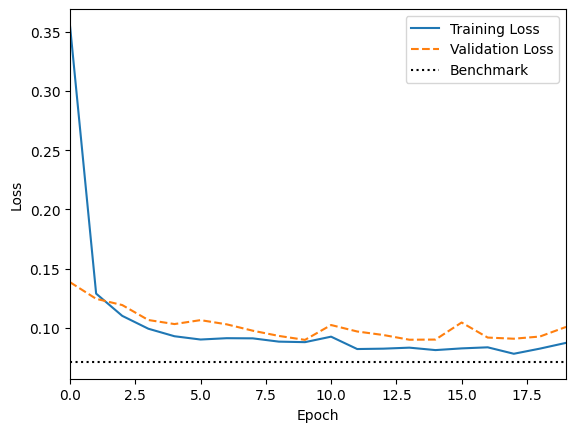

variance of returns for old data:  0.0017259802240189796
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(122.5259)
windows last2 price:  tensor(121.7809)
windows last3 price:  tensor(124.7112)
period from idx:  0  to idx  5
prediction at 5:  tensor(124.2402)
last price from test data:  122.52590942382812
real price 5 steps forward:  tensor(121.8802)
kelly weight:  {tensor(8.1061, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(121.8802)
windows last2 price:  tensor(120.3406)
windows last3 price:  tensor(120.6386)
period from idx:  5  to idx  10
prediction at 5:  tensor(124.8385)
last price from test data:  tensor(120.3406)
real price 5 steps forward:  tensor(123.7676)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(123.7676)
windows last2 price:  tensor(123.0226)
windows last3 price

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


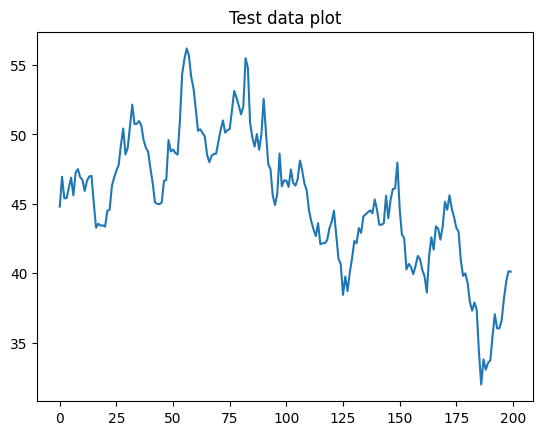

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 0.8234041032148975
Normalized Benchmark: 0.025931687250846887


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

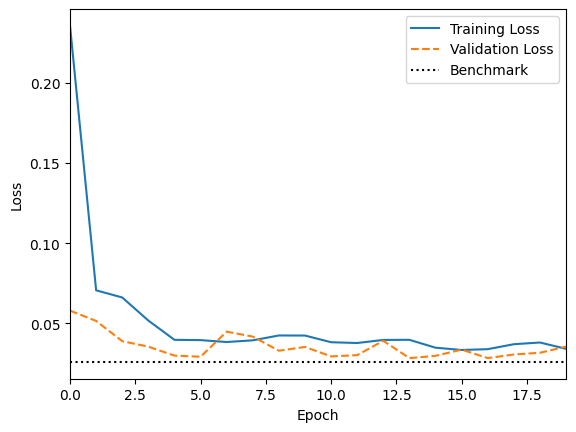

variance of returns for old data:  0.0021327729672193543
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(43.3000)
windows last2 price:  tensor(44.7200)
windows last3 price:  tensor(46.5200)
period from idx:  0  to idx  5
prediction at 5:  tensor(46.1785)
last price from test data:  43.29999923706055
real price 5 steps forward:  tensor(46.8900)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(46.8900)
windows last2 price:  tensor(46.1600)
windows last3 price:  tensor(45.4100)
period from idx:  5  to idx  10
prediction at 5:  tensor(46.7743)
last price from test data:  tensor(46.1600)
real price 5 steps forward:  tensor(46.7300)
kelly weight:  {tensor(6.2402, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(46.7300)
windows last2 price:  tensor(46.9100)
windows last3 price:  tensor(47.5

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


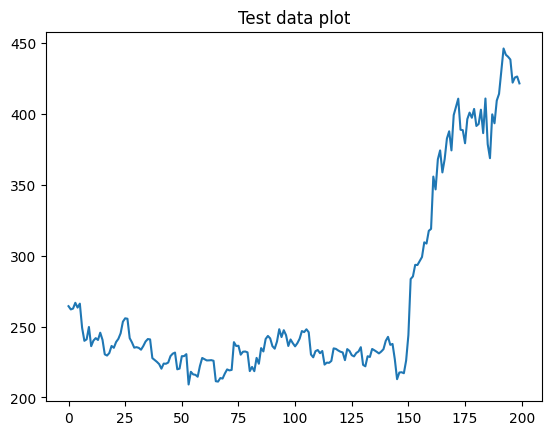

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.4351538202210752
Normalized Benchmark: 0.03735716023555043


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

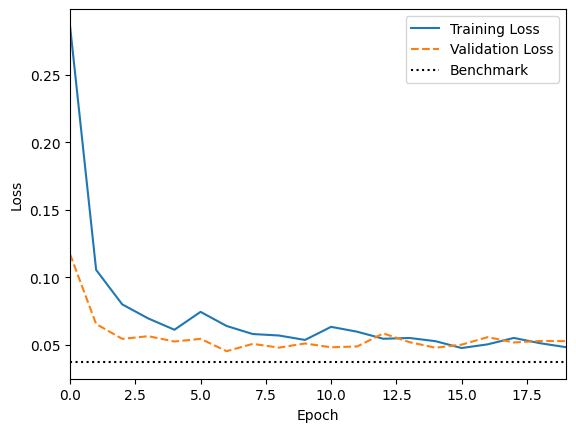

variance of returns for old data:  0.002112317566317719
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(264.1200)
windows last2 price:  tensor(255.4718)
windows last3 price:  tensor(255.2729)
period from idx:  0  to idx  5
prediction at 5:  tensor(245.3168)
last price from test data:  264.1200256347656
real price 5 steps forward:  tensor(266.1082)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(266.1082)
windows last2 price:  tensor(263.3247)
windows last3 price:  tensor(266.7045)
period from idx:  5  to idx  10
prediction at 5:  tensor(257.3570)
last price from test data:  tensor(263.3247)
real price 5 steps forward:  tensor(236.1374)
kelly weight:  {tensor(-10.7289, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(236.1374)
windows last2 price:  tensor(249.6565)
windows last3 pric

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


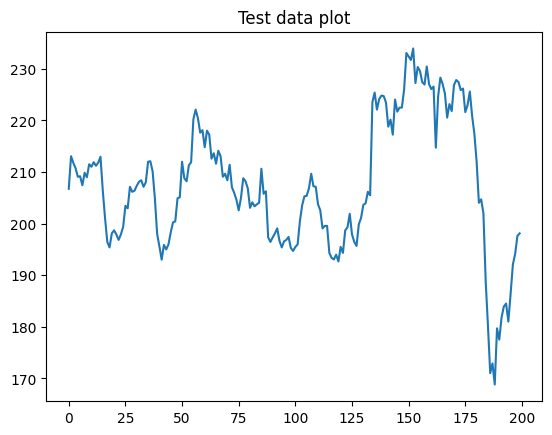

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.505005270799923
Normalized Benchmark: 0.04501610991104408


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

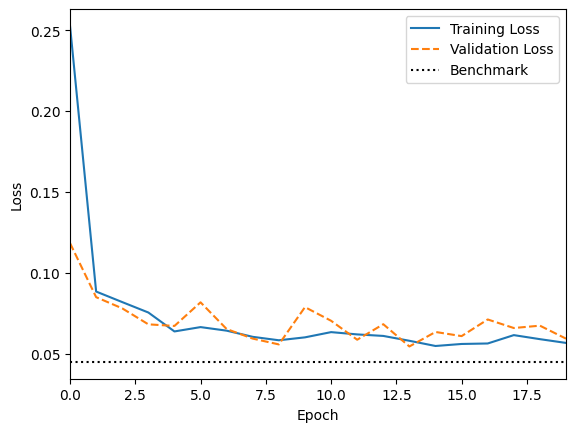

variance of returns for old data:  0.0019011827661622224
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(204.5199)
windows last2 price:  tensor(203.7426)
windows last3 price:  tensor(207.4347)
period from idx:  0  to idx  5
prediction at 5:  tensor(205.7551)
last price from test data:  204.5198974609375
real price 5 steps forward:  tensor(209.1835)
kelly weight:  {tensor(3.1767, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(209.1835)
windows last2 price:  tensor(209.0864)
windows last3 price:  tensor(210.7381)
period from idx:  5  to idx  10
prediction at 5:  tensor(208.0328)
last price from test data:  tensor(209.0864)
real price 5 steps forward:  tensor(211.0295)
kelly weight:  {tensor(-2.6503, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(211.0295)
windows last2 price:  tensor(211.5154)
windows last3 pr

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


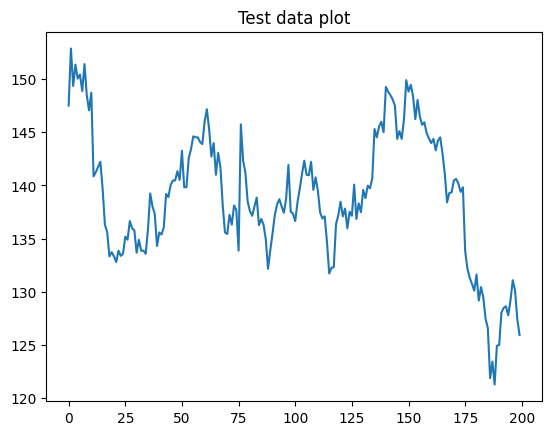

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.0793851817772513
Normalized Benchmark: 0.021180703729655814


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

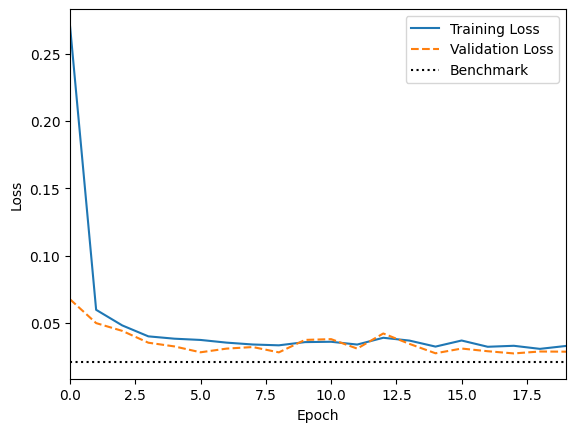

variance of returns for old data:  0.0017128258425887339
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(149.4583)
windows last2 price:  tensor(148.9211)
windows last3 price:  tensor(148.7257)
period from idx:  0  to idx  5
prediction at 5:  tensor(145.4748)
last price from test data:  149.45834350585938
real price 5 steps forward:  tensor(150.4352)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(150.4352)
windows last2 price:  tensor(150.0444)
windows last3 price:  tensor(151.3632)
period from idx:  5  to idx  10
prediction at 5:  tensor(147.2601)
last price from test data:  tensor(150.0444)
real price 5 steps forward:  tensor(148.7257)
kelly weight:  {tensor(-10.8339, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(148.7257)
windows last2 price:  tensor(147.0650)
windows last3 pr

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


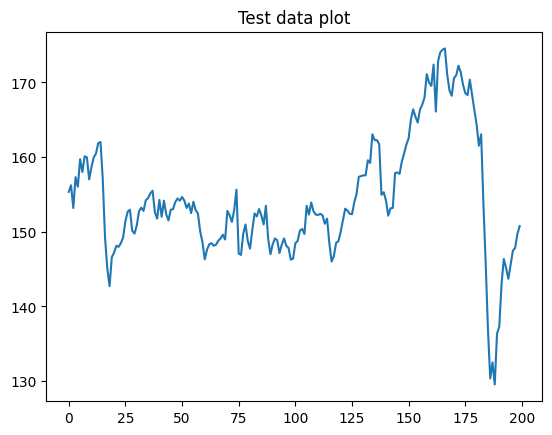

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.2961217694556153
Normalized Benchmark: 0.04355445950211379


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

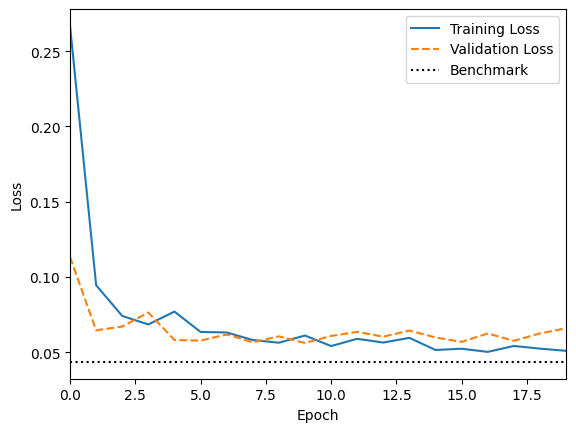

variance of returns for old data:  0.0022565365938968084
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(151.2177)
windows last2 price:  tensor(150.2849)
windows last3 price:  tensor(151.6596)
period from idx:  0  to idx  5
prediction at 5:  tensor(148.1047)
last price from test data:  151.21771240234375
real price 5 steps forward:  tensor(159.7114)
kelly weight:  {tensor(-9.1229, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(159.7114)
windows last2 price:  tensor(156.0292)
windows last3 price:  tensor(157.3057)
period from idx:  5  to idx  10
prediction at 5:  tensor(151.9918)
last price from test data:  tensor(156.0292)
real price 5 steps forward:  tensor(158.6313)
kelly weight:  {tensor(-11.4671, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(158.6313)
windows last2 price:  tensor(157.0111)
windows last3

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


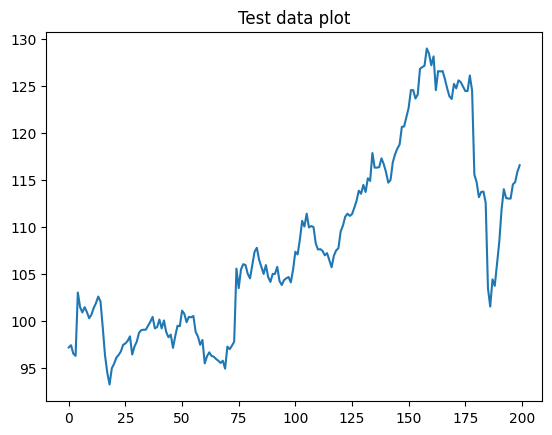

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.1821057129336663
Normalized Benchmark: 0.04639250579188849


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

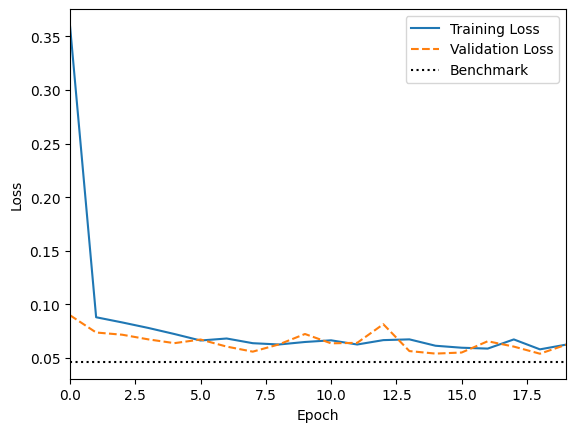

variance of returns for old data:  0.0013032223308030296
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.8744)
windows last2 price:  tensor(94.3182)
windows last3 price:  tensor(95.2142)
period from idx:  0  to idx  5
prediction at 5:  tensor(93.9076)
last price from test data:  95.87443542480467
real price 5 steps forward:  tensor(101.4392)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(101.4392)
windows last2 price:  tensor(102.9955)
windows last3 price:  tensor(96.2517)
period from idx:  5  to idx  10
prediction at 5:  tensor(99.0720)
last price from test data:  tensor(102.9955)
real price 5 steps forward:  tensor(100.6375)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.6375)
windows last2 price:  tensor(100.2602)
windows last3 price:  tenso

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


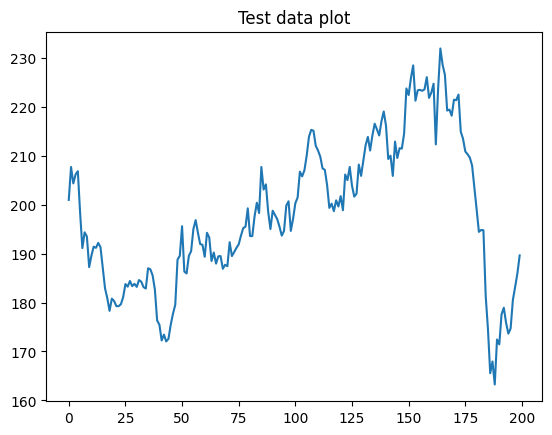

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.9293549090028193
Normalized Benchmark: 0.05649983116198244


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

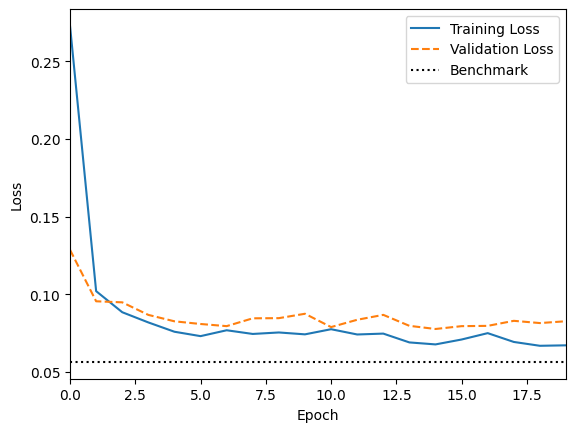

variance of returns for old data:  0.0018589664535711163
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(198.6008)
windows last2 price:  tensor(198.4085)
windows last3 price:  tensor(204.7560)
period from idx:  0  to idx  5
prediction at 5:  tensor(210.4943)
last price from test data:  198.60081481933597
real price 5 steps forward:  tensor(198.4085)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(198.4085)
windows last2 price:  tensor(206.8718)
windows last3 price:  tensor(206.1986)
period from idx:  5  to idx  10
prediction at 5:  tensor(211.9108)
last price from test data:  tensor(206.8718)
real price 5 steps forward:  tensor(189.6085)
kelly weight:  {tensor(13.1028, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(189.6085)
windows last2 price:  tensor(187.2522)
windows last3 pric

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


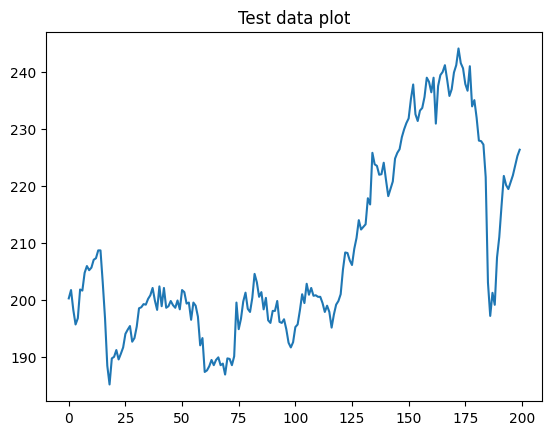

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.013671693611268
Normalized Benchmark: 0.045610018523028796


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

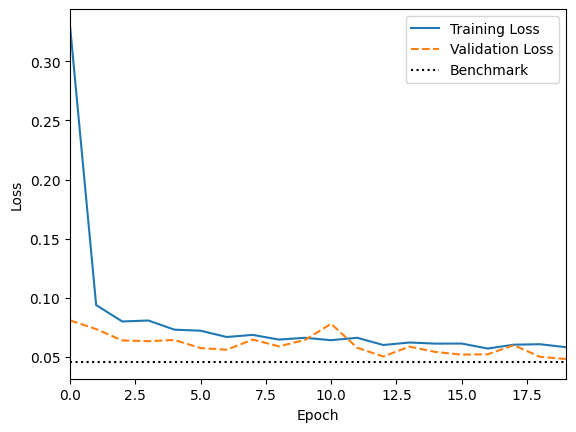

variance of returns for old data:  0.002089301609061629
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(196.3808)
windows last2 price:  tensor(193.4525)
windows last3 price:  tensor(197.4790)
period from idx:  0  to idx  5
prediction at 5:  tensor(195.9673)
last price from test data:  196.38082885742188
real price 5 steps forward:  tensor(201.7799)
kelly weight:  {tensor(-1.0080, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(201.7799)
windows last2 price:  tensor(196.7469)
windows last3 price:  tensor(195.6487)
period from idx:  5  to idx  10
prediction at 5:  tensor(199.0948)
last price from test data:  tensor(196.7469)
real price 5 steps forward:  tensor(205.6234)
kelly weight:  {tensor(5.7119, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(205.6234)
windows last2 price:  tensor(205.1658)
windows last3 pr

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


Shape dataset (6409, 11)
means:  Close           5.307977e+01
Volume          2.609046e+06
MarketCap       3.623076e+10
Weight          1.444499e-02
Return          3.644539e-04
LogReturn       1.553114e-04
WeightedRet     7.049176e-06
SMA20           5.295349e+01
EMA20           5.295416e+01
RSI14           5.179019e+01
ReturnVola20    1.809590e-02
dtype: float64
stds:  Close           2.570164e+01
Volume          2.088232e+06
MarketCap       1.754322e+10
Weight          4.131679e-03
Return          2.043817e-02
LogReturn       2.047098e-02
WeightedRet     3.104614e-04
SMA20           2.544732e+01
EMA20           2.542171e+01
RSI14           1.229032e+01
ReturnVola20    9.622688e-03
dtype: float64


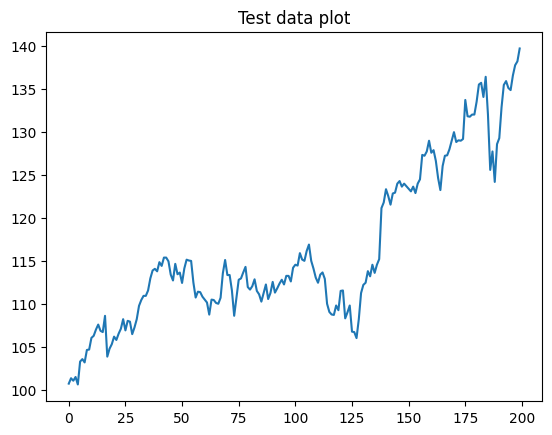

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.4684415752083775
Normalized Benchmark: 0.06372825151431728


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

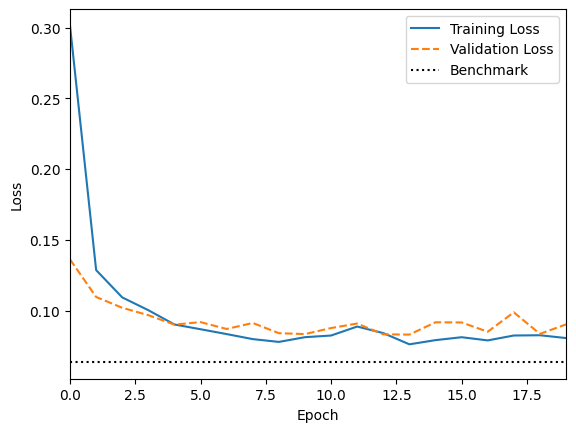

variance of returns for old data:  0.002081302204162834
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.3526)
windows last2 price:  tensor(99.0436)
windows last3 price:  tensor(98.8497)
period from idx:  0  to idx  5
prediction at 5:  tensor(102.0250)
last price from test data:  100.35257720947266
real price 5 steps forward:  tensor(103.2613)
kelly weight:  {tensor(8.0073, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(103.2613)
windows last2 price:  tensor(100.5950)
windows last3 price:  tensor(101.4676)
period from idx:  5  to idx  10
prediction at 5:  tensor(104.7626)
last price from test data:  tensor(100.5950)
real price 5 steps forward:  tensor(106.0247)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(106.0247)
windows last2 price:  tensor(104.6673)
windows last3 price:  

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


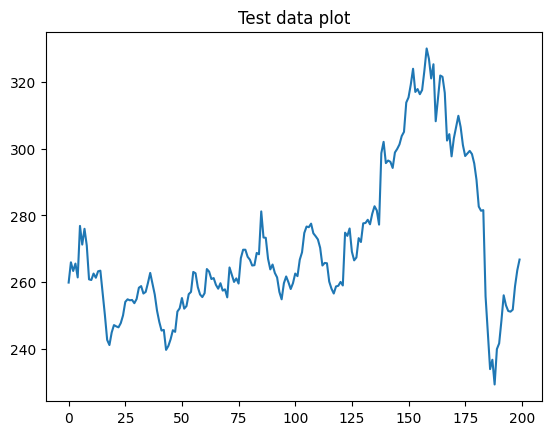

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.209860141011379
Normalized Benchmark: 0.038320928442702226


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

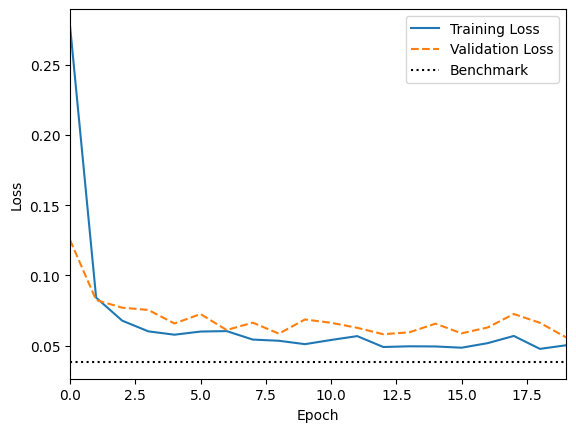

variance of returns for old data:  0.002025547322627374
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(256.8238)
windows last2 price:  tensor(253.7389)
windows last3 price:  tensor(256.9202)
period from idx:  0  to idx  5
prediction at 5:  tensor(257.7767)
last price from test data:  256.8238220214844
real price 5 steps forward:  tensor(276.8762)
kelly weight:  {tensor(1.8317, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(276.8762)
windows last2 price:  tensor(261.4513)
windows last3 price:  tensor(265.5967)
period from idx:  5  to idx  10
prediction at 5:  tensor(268.0157)
last price from test data:  tensor(261.4513)
real price 5 steps forward:  tensor(260.6800)
kelly weight:  {tensor(12.3954, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(260.6800)
windows last2 price:  tensor(260.8729)
windows last3 pri

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


In [3]:
from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionLSTMV1 import CrossAttentionLSTMV1
from train.train_functions import plot_training
import deeplay as dl

from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'KINV-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
tickers = all_tickers
#tickers = ['TEL2-B.ST']
epochs = 20
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)
    n_features = data_values.shape[1]
    train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_lstm_v1 = CrossAttentionLSTMV1(in_dim=n_features, hidden_dim=64, num_hidden_layers=5, out_dim=1, dropout=0.1, num_heads=16)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_lstm_v1
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)

(22, 200)
(200,)


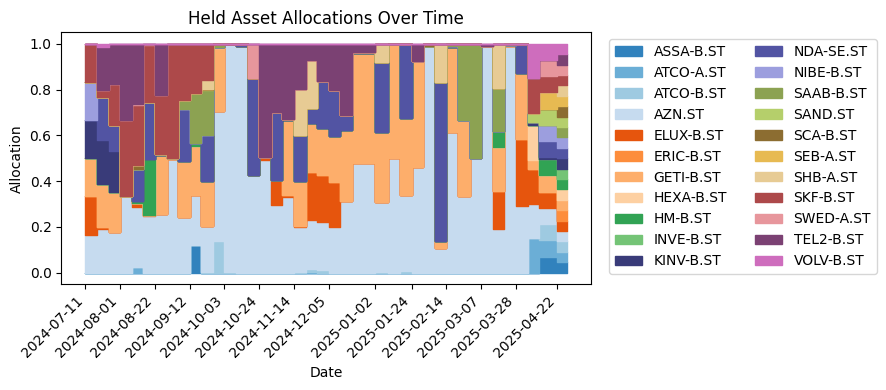

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
trading_cost = 0.005

from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations

test_indices = df.index[-num_test_points*22::22]
test_indices = test_indices[:int(horizon*np.floor(num_test_points/horizon))]

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers, dates):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()

    plt.tight_layout()
    plt.show()
#plot_allocations(alloc, tickers, test_indices)

def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# call with your alloc, tickers and test_indices as dates:
plot_allocations(alloc, tickers, test_indices)
#np.save('best_allocations.npy',alloc)

200
(22, 200)
(22, 200)
(200,)
Portfoliot final return:  1.2605136007552367
Index final return 0.96005725629508


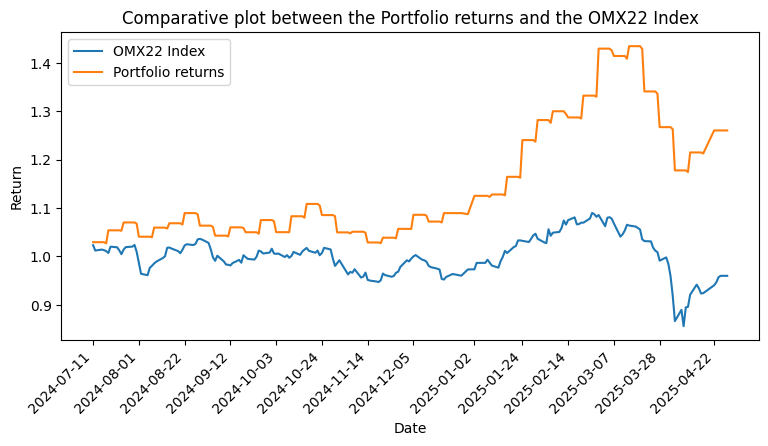

In [48]:
from allocation_functions.allocation_functions import calculate_asset_returns, calculate_portfolio_returns, calculate_cumulative_portfolio_returns, retrieve_test_closing_price
import matplotlib.pyplot as plt


print(len(test_indices))

returns = calculate_asset_returns(df, tickers, horizon, num_of_test_points=num_test_points)
print(alloc.shape)
print(returns.shape)

portfolio_returns = calculate_portfolio_returns(alloc, returns[:,:alloc.shape[1]])
print(portfolio_returns.shape)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
#print(portfolio_returns_with_tradingcost)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print('Portfoliot final return: ',portfolio_cum_return[-1])



df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:].values

index_diffs = np.diff(index_test_values, axis=0)
index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
#print(index_diffs)
cum_prod_index = 1 * np.cumprod(1 + index_diffs)
cum_prod_index = cum_prod_index[:int(horizon*np.floor(num_test_points/horizon))]
print('Index final return', cum_prod_index[-1])
plt.figure(figsize=(9,4))
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.xticks(
        test_indices[::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.legend()



torch.Size([13, 50, 50])
Randomly selected samples: [6, 5, 7, 2]


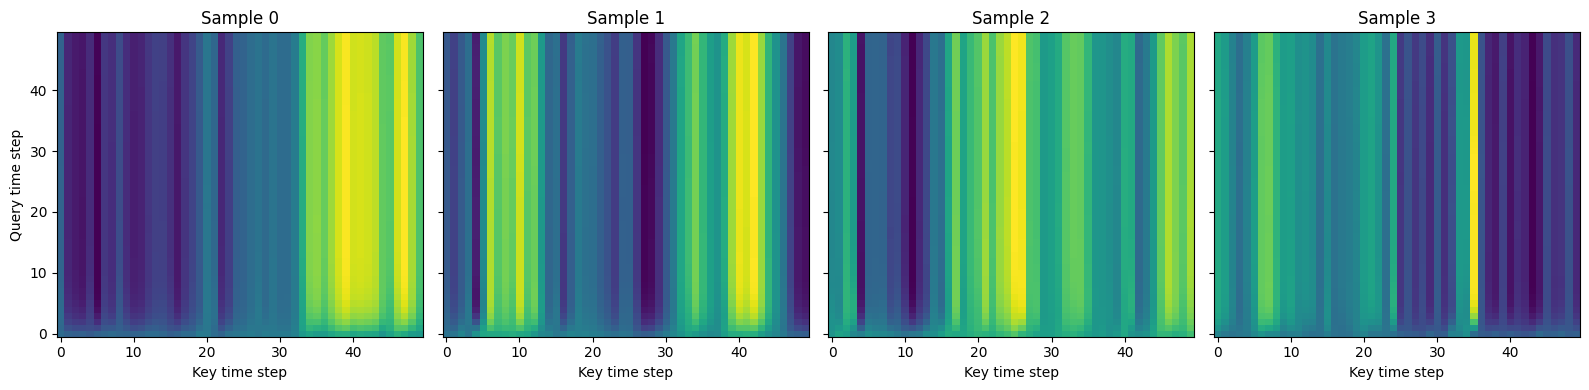

TypeError: Invalid shape (1, 50, 50) for image data

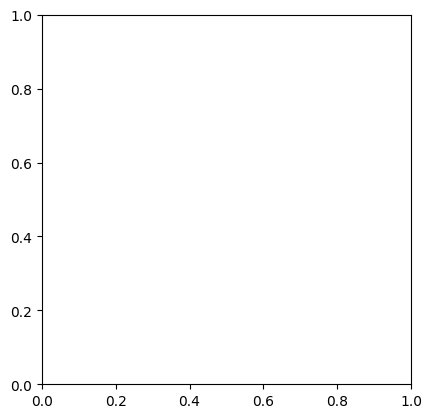

In [15]:
import torch
cross_attn_lstm_v1.eval()

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        x_batch, y_batch = batch
        #print(y_batch)
        test_prediction = cross_attn_lstm_v1(x_batch)
        attn_weights = cross_attn_lstm_v1.get_attn_weights()
        all_attn = attn_weights
        if i > 5:
            break
        
print(all_attn.shape)
attn = all_attn.detach().cpu().numpy()  
#attn = all_attn[0].detach().cpu().numpy() 
 
import random
#random.seed(42)
indices = random.sample(range(21), 4)
print("Randomly selected samples:", indices)

attn4 = attn[indices]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

im_mean = attn4.mean(0, keepdims=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        attn4[i],
        origin="lower",
        cmap="viridis",
        aspect="auto", 
       
    )
    ax.set_title(f"Sample {i}")
    ax.set_xlabel("Key time step")
    if i == 0:
        ax.set_ylabel("Query time step")



plt.tight_layout()
plt.show()

plt.imshow(im_mean)
plt.show()